In [ ]:
!pip install xgboost opencv-python kagglehub tensorflow -q

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

In [ ]:
#random seed
np.random.seed(42)
tf.random.set_seed(42)
os.makedirs("outputs", exist_ok=True)

In [ ]:
#path
path = kagglehub.dataset_download(
    "sartajbhuvaji/brain-tumor-classification-mri"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Dataset Path: /kaggle/input/brain-tumor-classification-mri


In [ ]:
#define class
classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

In [ ]:
#load dataset
IMG_SIZE = 224

def load_images(folder_path):

    X = []
    Y = []

    for cls, label in classes.items():

        class_path = os.path.join(folder_path, cls)

        for filename in os.listdir(class_path):

            img_path = os.path.join(class_path, filename)

            img = cv2.imread(img_path)

            if img is not None:

                img = cv2.cvtColor(
                    img,
                    cv2.COLOR_BGR2RGB
                )

                img = cv2.resize(
                    img,
                    (IMG_SIZE, IMG_SIZE)
                )

                X.append(img)

                Y.append(label)

    return np.array(X, dtype=np.float32), np.array(Y)


# LOAD TRAINING DATA
train_path = os.path.join(path, "Training")

print("Loading Training Images...")

X_train_raw, Y_train = load_images(train_path)

# LOAD TESTING DATA
test_path = os.path.join(path, "Testing")

print("Loading Testing Images...")

X_test_raw, Y_test = load_images(test_path)

print("Training Shape :", X_train_raw.shape)
print("Testing Shape  :", X_test_raw.shape)

Loading Training Images...
Loading Testing Images...
Training Shape : (2870, 224, 224, 3)
Testing Shape  : (394, 224, 224, 3)


In [ ]:
#build vgg16 feature extractor
print("Building VGG16 Feature Extractor...")

base_vgg = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_vgg.trainable = False

gap_output = tf.keras.layers.GlobalAveragePooling2D()(
    base_vgg.output
)

extractor = Model(
    inputs=base_vgg.input,
    outputs=gap_output
)

extractor.summary()

Building VGG16 Feature Extractor...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
#extract vgg16 features
BATCH = 32

# TRAIN FEATURES
X_train_preprocessed = preprocess_input(
    X_train_raw.copy()
)

train_features = []

for i in range(0, len(X_train_preprocessed), BATCH):

    batch_features = extractor.predict(
        X_train_preprocessed[i:i+BATCH],
        verbose=0
    )

    train_features.append(batch_features)

X_train_feats = np.vstack(train_features)

# TEST FEATURES
X_test_preprocessed = preprocess_input(
    X_test_raw.copy()
)

test_features = []

for i in range(0, len(X_test_preprocessed), BATCH):

    batch_features = extractor.predict(
        X_test_preprocessed[i:i+BATCH],
        verbose=0
    )

    test_features.append(batch_features)

X_test_feats = np.vstack(test_features)

print("Train Feature Shape :", X_train_feats.shape)
print("Test Feature Shape  :", X_test_feats.shape)

Train Feature Shape : (2870, 512)
Test Feature Shape  : (394, 512)


In [ ]:
#training percentages
train_sizes = [0.2, 0.4, 0.6, 0.8]


TRAINING DATA USED : 20%
TESTING DATA USED  : 100% Official Test Set

Training VGG16 + XGBoost...
Training Completed
Training Accuracy : 0.9982578397212544
Testing Accuracy  : 0.6345177664974619
F1 Score          : 0.6206420789540703

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.74      0.72      0.73       105
 Pituitary Tumor       0.64      0.84      0.73        74
    Glioma Tumor       0.58      0.33      0.42       100
Meningioma Tumor       0.58      0.69      0.63       115

        accuracy                           0.63       394
       macro avg       0.63      0.64      0.63       394
    weighted avg       0.63      0.63      0.62       394



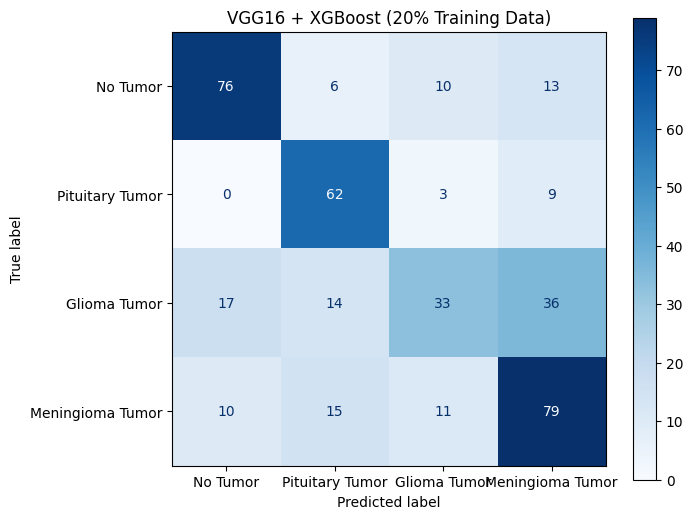


TRAINING DATA USED : 40%
TESTING DATA USED  : 100% Official Test Set

Training VGG16 + XGBoost...
Training Completed
Training Accuracy : 0.9599303135888502
Testing Accuracy  : 0.6624365482233503
F1 Score          : 0.6426778311493132

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.68      0.81      0.74       105
 Pituitary Tumor       0.77      0.76      0.76        74
    Glioma Tumor       0.64      0.30      0.41       100
Meningioma Tumor       0.60      0.78      0.68       115

        accuracy                           0.66       394
       macro avg       0.67      0.66      0.65       394
    weighted avg       0.66      0.66      0.64       394



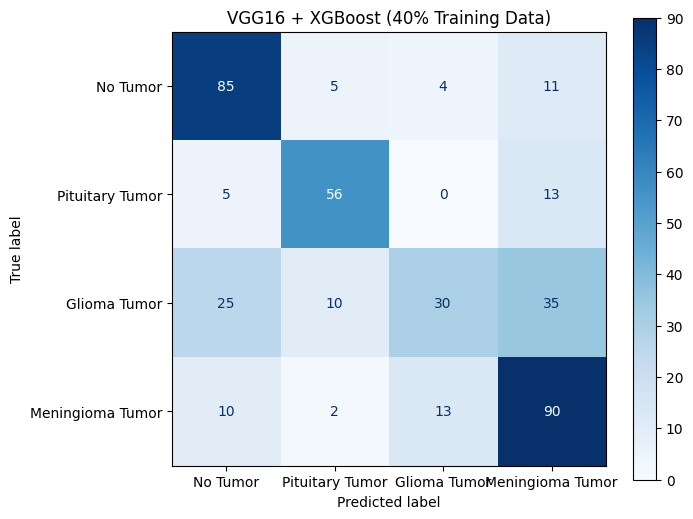


TRAINING DATA USED : 60%
TESTING DATA USED  : 100% Official Test Set

Training VGG16 + XGBoost...
Training Completed
Training Accuracy : 0.9454123112659698
Testing Accuracy  : 0.6979695431472082
F1 Score          : 0.6777665774957032

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.68      0.85      0.75       105
 Pituitary Tumor       0.78      0.80      0.79        74
    Glioma Tumor       0.75      0.33      0.46       100
Meningioma Tumor       0.66      0.82      0.73       115

        accuracy                           0.70       394
       macro avg       0.72      0.70      0.68       394
    weighted avg       0.71      0.70      0.68       394



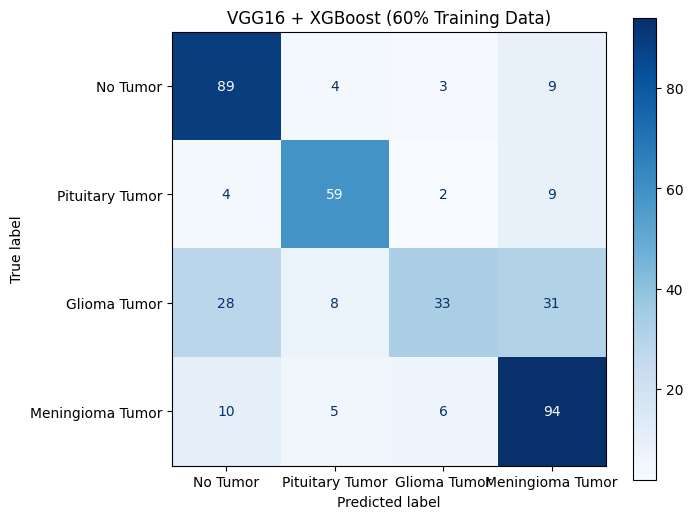


TRAINING DATA USED : 80%
TESTING DATA USED  : 100% Official Test Set

Training VGG16 + XGBoost...
Training Completed
Training Accuracy : 0.9259581881533101
Testing Accuracy  : 0.7182741116751269
F1 Score          : 0.6947714711171582

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.72      0.91      0.81       105
 Pituitary Tumor       0.87      0.80      0.83        74
    Glioma Tumor       0.79      0.31      0.45       100
Meningioma Tumor       0.63      0.84      0.72       115

        accuracy                           0.72       394
       macro avg       0.75      0.72      0.70       394
    weighted avg       0.74      0.72      0.69       394



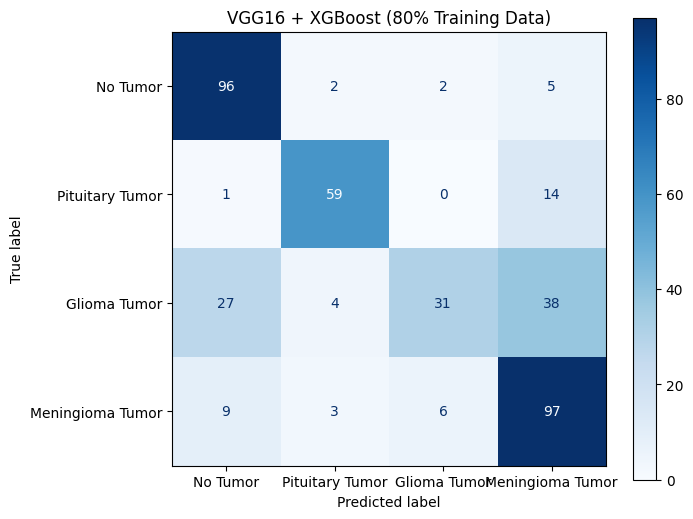

In [ ]:
#vgg16+xgboost
vgg_train_acc = []

vgg_test_acc = []

vgg_f1 = []

labels = []

for train_size in train_sizes:

    print("\n====================================")

    print(f"TRAINING DATA USED : {int(train_size*100)}%")

    print("TESTING DATA USED  : 100% Official Test Set")

    print("====================================")

    # TAKE SUBSET OF TRAINING DATA
    xtrain_v, _, ytrain_v, _ = train_test_split(
        X_train_feats,
        Y_train,
        train_size=train_size,
        random_state=42,
        stratify=Y_train
    )

    # XGBOOST MODEL
    xgb_vgg = XGBClassifier(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    print("\nTraining VGG16 + XGBoost...")

    xgb_vgg.fit(
        xtrain_v,
        ytrain_v
    )

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb_vgg.predict(xtrain_v)

    test_pred = xgb_vgg.predict(X_test_feats)

    # METRICS
    train_acc = accuracy_score(
        ytrain_v,
        train_pred
    )

    test_acc = accuracy_score(
        Y_test,
        test_pred
    )

    f1 = f1_score(
        Y_test,
        test_pred,
        average='weighted'
    )

    print("Training Accuracy :", train_acc)

    print("Testing Accuracy  :", test_acc)

    print("F1 Score          :", f1)

    vgg_train_acc.append(train_acc)

    vgg_test_acc.append(test_acc)

    vgg_f1.append(f1)

    labels.append(
        f"{int(train_size*100)}%"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            Y_test,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    cm = confusion_matrix(
        Y_test,
        test_pred
    )

    fig, ax = plt.subplots(figsize=(7,6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=True
    )

    plt.title(
        f"VGG16 + XGBoost ({int(train_size*100)}% Training Data)"
    )

    plt.show()

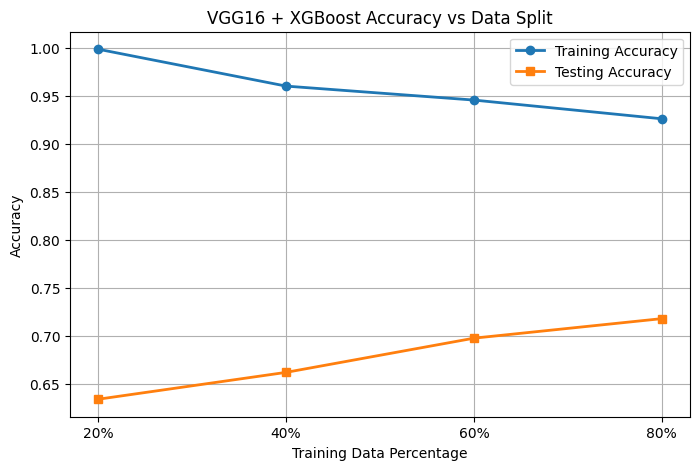

In [ ]:
#accuracy plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    vgg_train_acc,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    vgg_test_acc,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("VGG16 + XGBoost Accuracy vs Data Split")

plt.legend()

plt.grid(True)

plt.show()

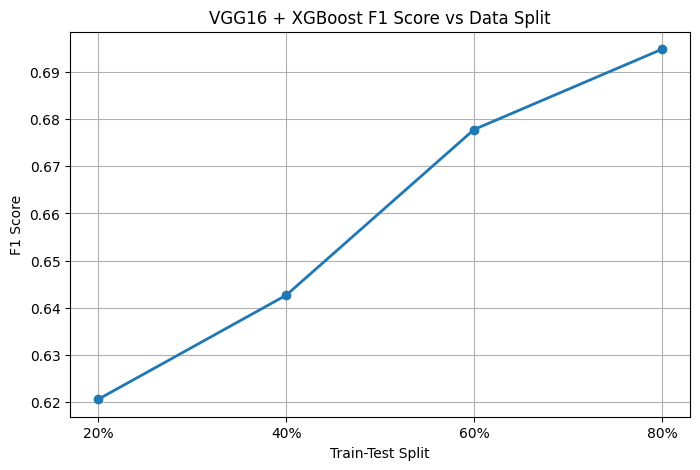

In [ ]:
#f1 plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    vgg_f1,
    marker='o',
    linewidth=2
)

plt.xlabel("Train-Test Split")

plt.ylabel("F1 Score")

plt.title("VGG16 + XGBoost F1 Score vs Data Split")

plt.grid(True)

plt.show()

In [ ]:
#results table
results_df = pd.DataFrame({
    'Training Data Used': labels,
    'Training Accuracy': vgg_train_acc,
    'Testing Accuracy': vgg_test_acc,
    'F1 Score': vgg_f1
})

print(results_df)

  Training Data Used  Training Accuracy  Testing Accuracy  F1 Score
0                20%           0.998258          0.634518  0.620642
1                40%           0.959930          0.662437  0.642678
2                60%           0.945412          0.697970  0.677767
3                80%           0.925958          0.718274  0.694771


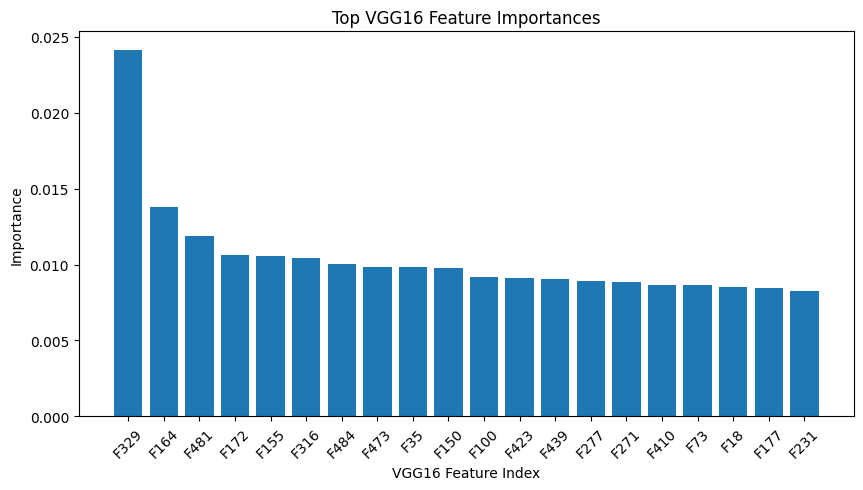

In [ ]:
#feature importance
importances = xgb_vgg.feature_importances_

top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10,5))

plt.bar(
    range(20),
    importances[top_idx]
)

plt.xticks(
    range(20),
    [f"F{idx+1}" for idx in top_idx],
    rotation=45
)

plt.xlabel("VGG16 Feature Index")

plt.ylabel("Importance")

plt.title("Top VGG16 Feature Importances")

plt.show()

In [ ]:
#sample predictions
test_path = os.path.join(path, "Testing")

def display_samples_vgg(folder, title, num_samples=9):

    valid_ext = ('.jpg', '.jpeg', '.png')

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    files = files[:num_samples]

    plt.figure(figsize=(12,8))

    for i, filename in enumerate(files):

        img_path = os.path.join(folder, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img_resized = cv2.resize(
            img_rgb,
            (224,224)
        )

        img_input = preprocess_input(
            np.expand_dims(
                img_resized.astype(np.float32),
                axis=0
            )
        )

        feat = extractor.predict(
            img_input,
            verbose=0
        )

        pred = xgb_vgg.predict(feat)[0]
        plt.subplot(3,3,i+1)
        plt.imshow(img_resized)
        plt.title(dec[pred])
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

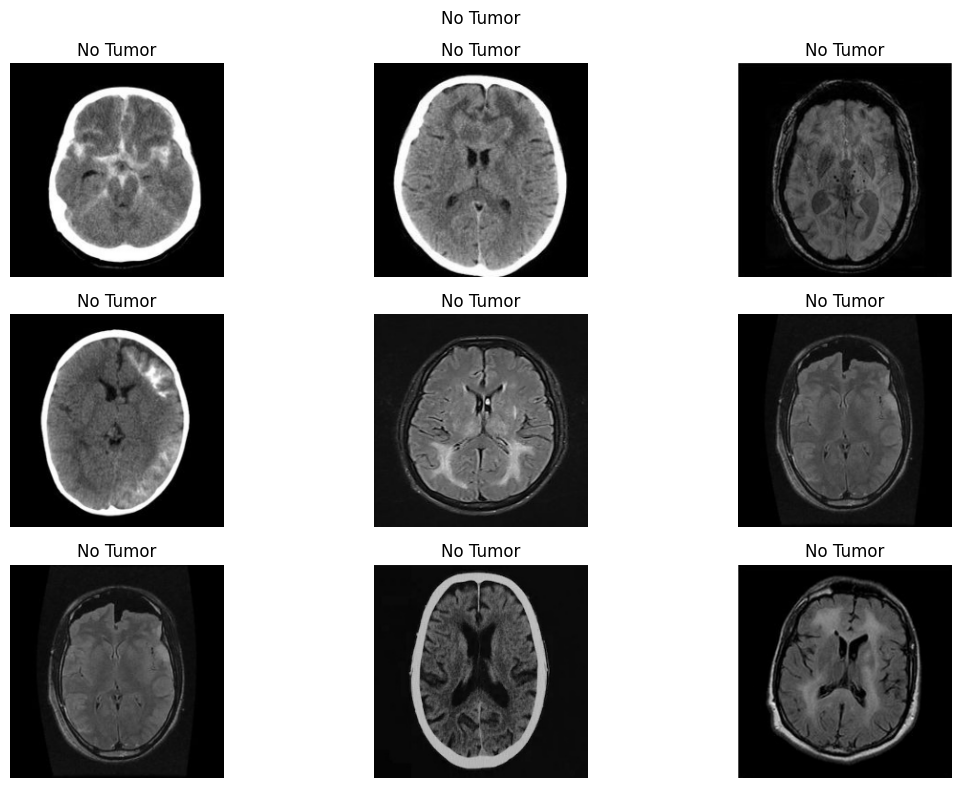

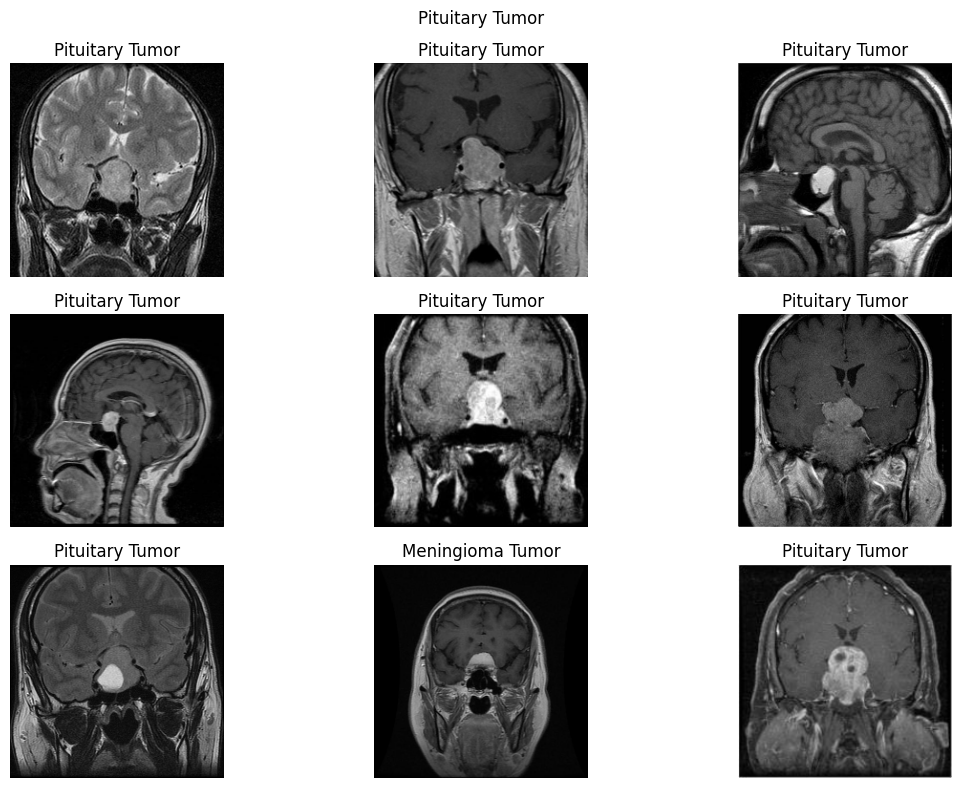

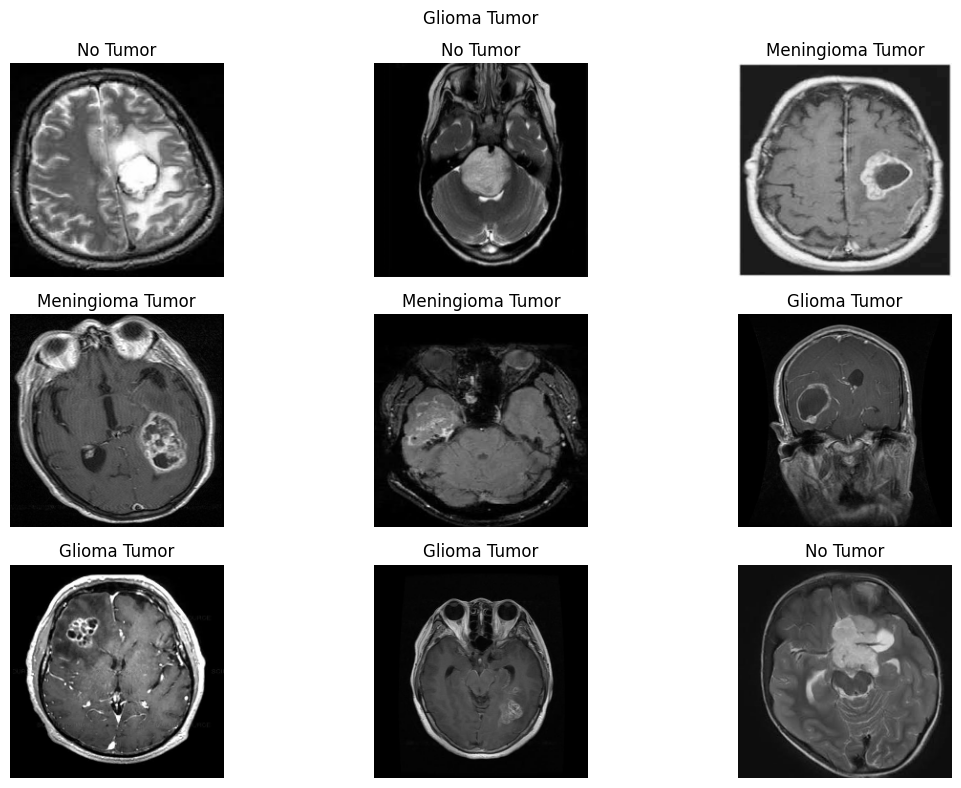

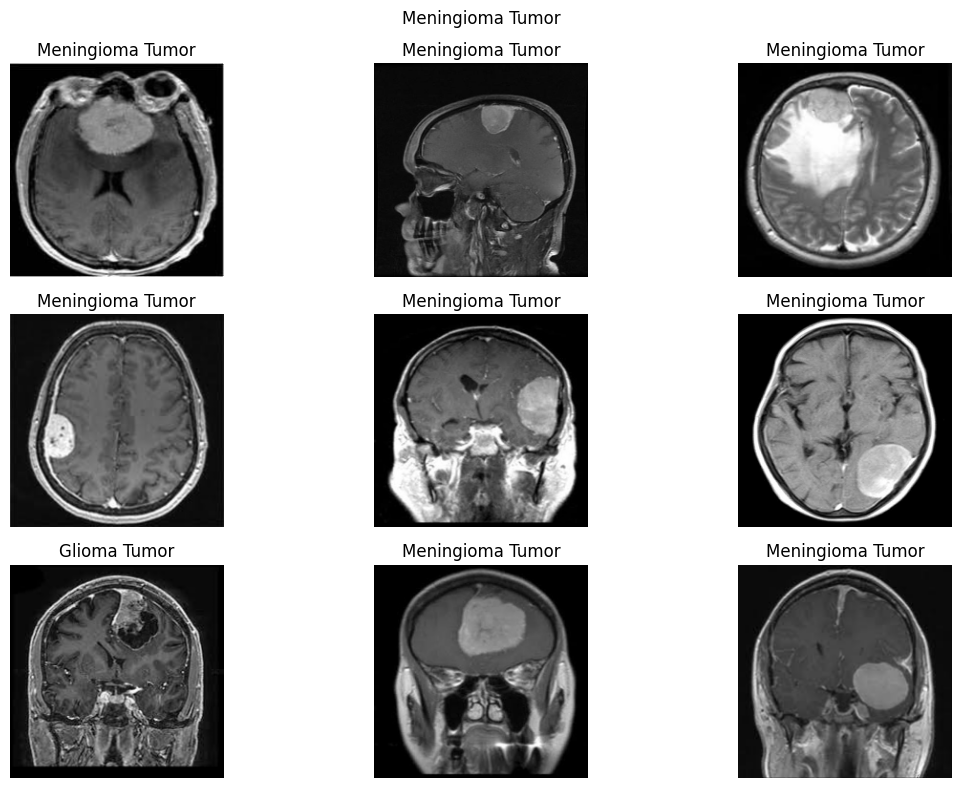

In [ ]:
# display predictions
for tumor_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        tumor_folder
    )

    if os.path.isdir(folder_path):

        display_samples_vgg(
            folder_path,
            tumor_folder.replace("_"," ").title()
        )